# Theorem 13 
Is the empirical generalization gap bounded above as described in theorem 13?

In [1]:
%load_ext autoreload
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from fastnanoid import generate
from datetime import datetime

In [2]:
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [3]:
%autoreload 2
from lib.graph_factory import GraphFactory
from lib.proj_const_estimator import ProjConstEstimator
from lib.utils import fetch_dataset, get_alphas, rng, seed
from lib.classifier import ByzClassifier
from lib.system import SystemSimulator
from lib.config import BASE_CONF, LOGFILE, NUM_NODES

In [4]:
RUN_DIR = Path().resolve()
config = BASE_CONF

In [5]:
global_dataset = fetch_dataset('MNIST')
gf = GraphFactory(config['train']['num_nodes'], config['train']['b'], seed('graph'))
proj_const_estimator = ProjConstEstimator(config, global_dataset, rng('proj-const-estimator')) 
classifier = ByzClassifier(config, global_dataset, rng('byz-classifier'))
sys_sim = SystemSimulator(config, global_dataset, rng('ml-system-sim'), LOGFILE)

In [6]:
proj_const_estimator.configure(gf,config)
proj_const = proj_const_estimator.estimate()

In [7]:
%%time
classifier.configure(gf,config, proj_const)
X_C_train, y_C_train, X_C_test, y_C_test = classifier.run_simulations()
classifier_metrics = classifier.train_and_eval(X_C_train, y_C_train, X_C_test, y_C_test)
C_opt_pt = classifier.clac_opt_operating_pt(0.7)
C_best_est, C_pre_pipe = classifier.get_params()

CPU times: user 8min 47s, sys: 8.7 s, total: 8min 56s
Wall time: 39.1 s


In [8]:
%%time
sim_params = {
'algorithms':['RDSGD'],
'atk_type':config['sys']['atk_type'],
'threat_model':'T3'
}

run_results = dict()
RUN_ID = generate()
run_results['timestamp'] = pd.to_datetime(datetime.now())
run_results['proj_const'] = proj_const
run_results.update(C_opt_pt)

sys_sim.configure(gf, config, proj_const, C_pre_pipe, C_best_est, C_opt_pt)
df = sys_sim.simulate(sim_params, run_results)
run_results['min_test_loss'] = df.loc['RDSGD']['min_test_loss'].min()
run_results['max_test_loss'] = df.loc['RDSGD']['max_test_loss'].max()
payload = sys_sim.log_results(run_results, RUN_DIR, RUN_ID)

==========RDSGD==========
[k=35] train_loss=1.5998
[k=70] train_loss=1.5879
[k=105] train_loss=1.5853
CPU times: user 15min 35s, sys: 5.74 s, total: 15min 41s
Wall time: 44.6 s


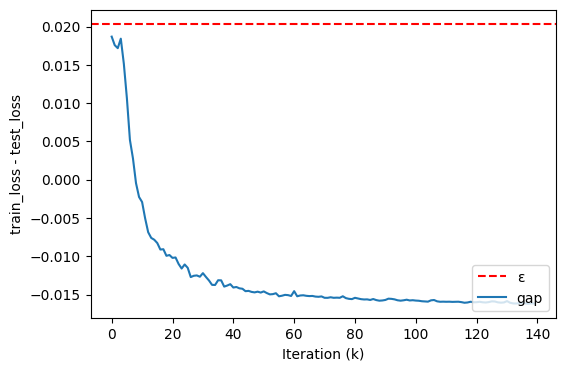

In [22]:
fig, ax = plt.subplots(1,1, figsize=(6,4))

iter_idx = np.arange(config['sys']['K'])
ax.axhline(y=payload['epsilon'], color='red', ls='--', label="ε")
ax.plot(iter_idx, df.loc['RDSGD']['train_loss'] - df.loc['RDSGD']['min_test_loss'], label='gap')
# ax.plot(iter_idx, df.loc['RDSGD']['train_loss'] - df.loc['RDSGD']['max_test_loss'], label='LB)')
ax.set_xlabel('Iteration (k)')
ax.set_ylabel('train_loss - test_loss')
ax.legend(loc='lower right')
plt.show()

In [23]:
images_dir = project_root / RUN_DIR / "images"
images_dir.mkdir(parents=True, exist_ok=True)
full_path = images_dir / "results.png"
fig.savefig(full_path, bbox_inches='tight', dpi=300)